In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../../../data/alternative/student_modeling_table.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 23)


,user_id,age,program_level,living_status,academic_year,maturity_score,gpa_latest,major_income_potential,loan_amount,debt_ratio,...,severe_behavior_flag,support_numeric,has_buffer,thin_support_flag,debt_x_behavior,debt_x_support,debt_x_living,behavior_under_pressure,shock_vulnerability,default
0,299bd021-6ddf-430d-bd32-e233c811ff06,18,university,dorm,1,0.25,2.65,medium,26195478,0.247,...,0,0.0,0,0,0.3705,0.0000,0.0000,0.3705,1,1
1,eabd69ad-856e-44db-82f4-0b6853be4b43,19,university,dorm,2,0.50,2.35,medium,26711415,0.260,...,0,-0.5,0,0,0.3900,-0.1300,0.0000,0.3900,1,1
2,2b793597-1a28-4a88-965c-e2e9f39cb6ae,23,university,family,1,0.25,2.22,medium,33165542,0.326,...,1,0.0,0,0,0.7172,0.0000,-0.0978,0.7172,1,0
3,e47e4c0b-d491-465a-b2e8-f19ba497e205,23,university,family,1,0.25,1.53,low,25544132,0.339,...,0,-0.5,0,0,0.1695,-0.1695,-0.1017,0.1695,1,0
4,09a202f9-8186-4143-a0a3-01f9ae921411,18,university,rent,1,0.25,1.75,low,31286502,0.446,...,0,0.5,0,1,0.6690,0.2230,0.1338,0.6690,2,1


In [2]:
print('=== Data Types & Non-null Counts ===')
df.info()
print()
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values ✅')
print()
print('=== Duplicates ===')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Unique user_ids: {df["user_id"].nunique()} / {len(df)}')

=== Data Types & Non-null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10000 non-null  object 
 1   age                      10000 non-null  int64  
 2   program_level            10000 non-null  object 
 3   living_status            10000 non-null  object 
 4   academic_year            10000 non-null  int64  
 5   maturity_score           10000 non-null  float64
 6   gpa_latest               10000 non-null  float64
 7   major_income_potential   10000 non-null  object 
 8   loan_amount              10000 non-null  int64  
 9   debt_ratio               10000 non-null  float64
 10  high_pressure_flag       10000 non-null  int64  
 11  behavior_risk_score      10000 non-null  float64
 12  behavior_volatility      10000 non-null  float64
 13  severe_behavior_flag     10000 non-null 

In [3]:
print('=== Descriptive Statistics (Numeric) ===')
df.describe().T.round(3)

=== Descriptive Statistics (Numeric) ===


,count,mean,std,min,25%,50%,75%,max
age,10000.0,2.101300e+01,2.009,18.000,1.900000e+01,2.100000e+01,2.300000e+01,2.400000e+01
academic_year,10000.0,2.343000e+00,1.066,1.000,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00
maturity_score,10000.0,6.620000e-01,0.265,0.250,5.000000e-01,7.500000e-01,1.000000e+00,1.000000e+00
gpa_latest,10000.0,2.002000e+00,0.927,0.000,1.300000e+00,2.000000e+00,2.720000e+00,4.000000e+00
loan_amount,10000.0,2.447369e+07,7440835.836,4912966.000,1.805390e+07,2.566698e+07,3.067828e+07,3.967357e+07
debt_ratio,10000.0,2.600000e-01,0.098,0.036,1.850000e-01,2.450000e-01,3.280000e-01,5.250000e-01
high_pressure_flag,10000.0,4.000000e-03,0.059,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
behavior_risk_score,10000.0,1.277000e+00,0.993,-2.000,5.000000e-01,1.500000e+00,2.200000e+00,2.200000e+00
behavior_volatility,10000.0,6.520000e-01,0.332,0.000,3.330000e-01,6.670000e-01,1.000000e+00,1.000000e+00
severe_behavior_flag,10000.0,3.670000e-01,0.482,0.000,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


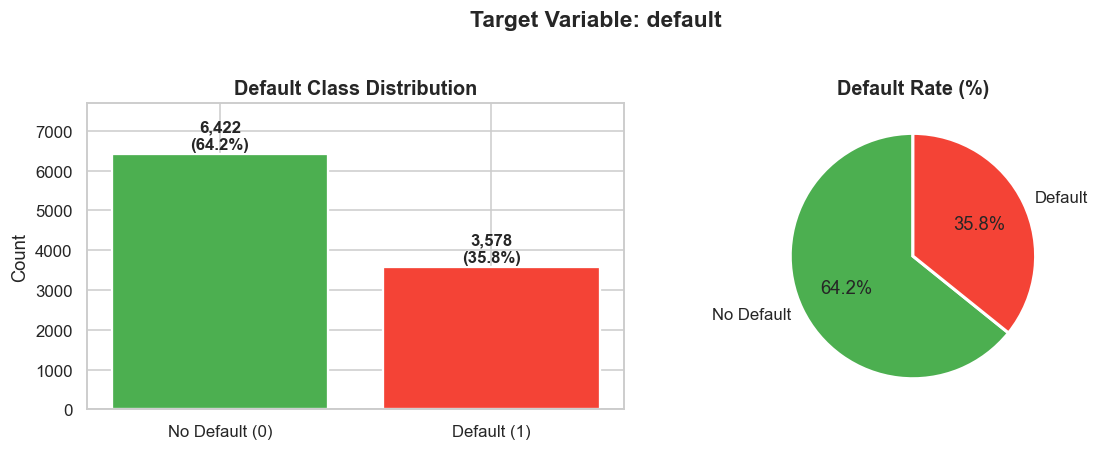


Class balance → 0: 64.2%  |  1: 35.8%
Imbalance ratio (0:1) = 1.79


In [4]:
target_counts = df['default'].value_counts()
target_pct    = df['default'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#4CAF50', '#F44336']
bars = axes[0].bar(['No Default (0)', 'Default (1)'], target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Default Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(target_counts.values) * 1.2)

# Pie chart
axes[1].pie(target_counts.values, labels=['No Default', 'Default'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Default Rate (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: default', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nClass balance → 0: {target_pct[0]:.1f}%  |  1: {target_pct[1]:.1f}%")
imbalance_ratio = target_counts[0] / target_counts[1]
print(f"Imbalance ratio (0:1) = {imbalance_ratio:.2f}")

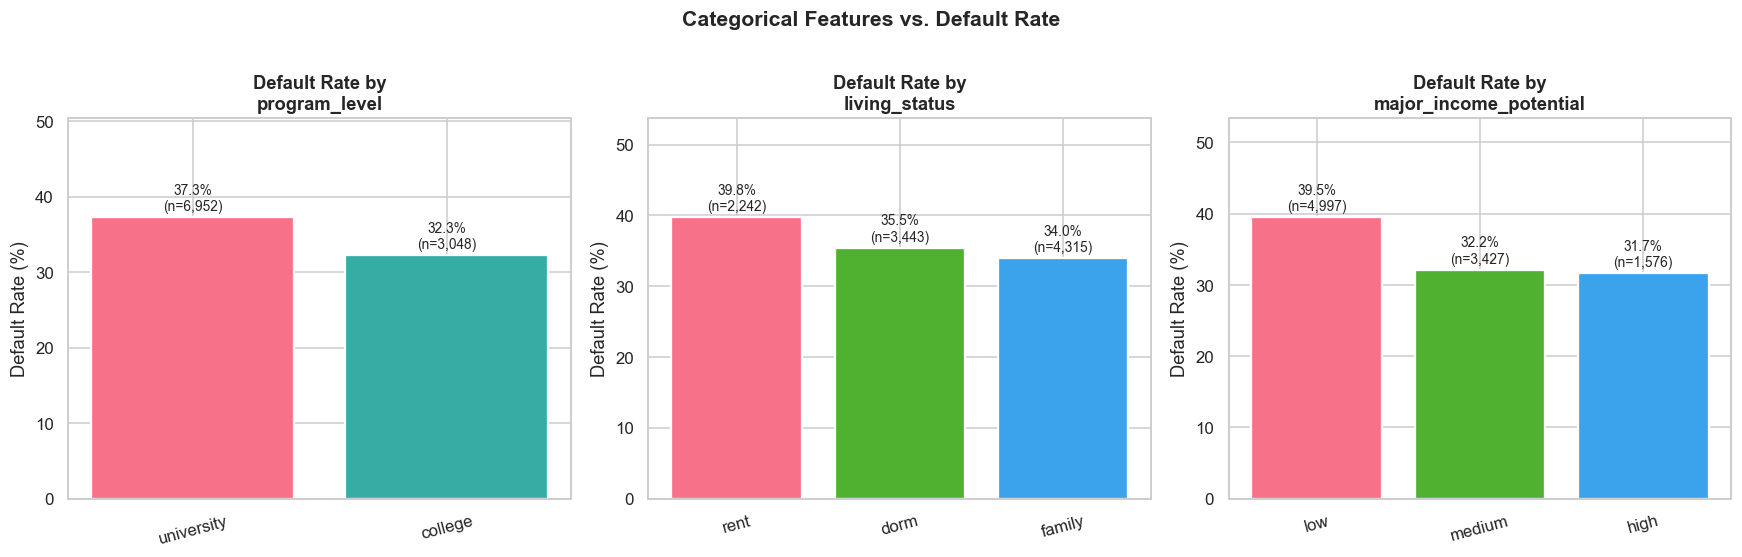

In [5]:
cat_features = ['program_level', 'living_status', 'major_income_potential']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_features):
    # Default rate by category
    stats = df.groupby(col)['default'].agg(['mean', 'count']).reset_index()
    stats['mean'] *= 100
    stats = stats.sort_values('mean', ascending=False)
    
    bars = ax.bar(stats[col], stats['mean'],
                  color=sns.color_palette('husl', len(stats)),
                  edgecolor='white', linewidth=1.5)
    for bar, row in zip(bars, stats.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{row.mean:.1f}%\n(n={row.count:,})',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Default Rate by\n{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Default Rate (%)')
    ax.set_ylim(0, stats['mean'].max() * 1.35)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Categorical Features vs. Default Rate', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

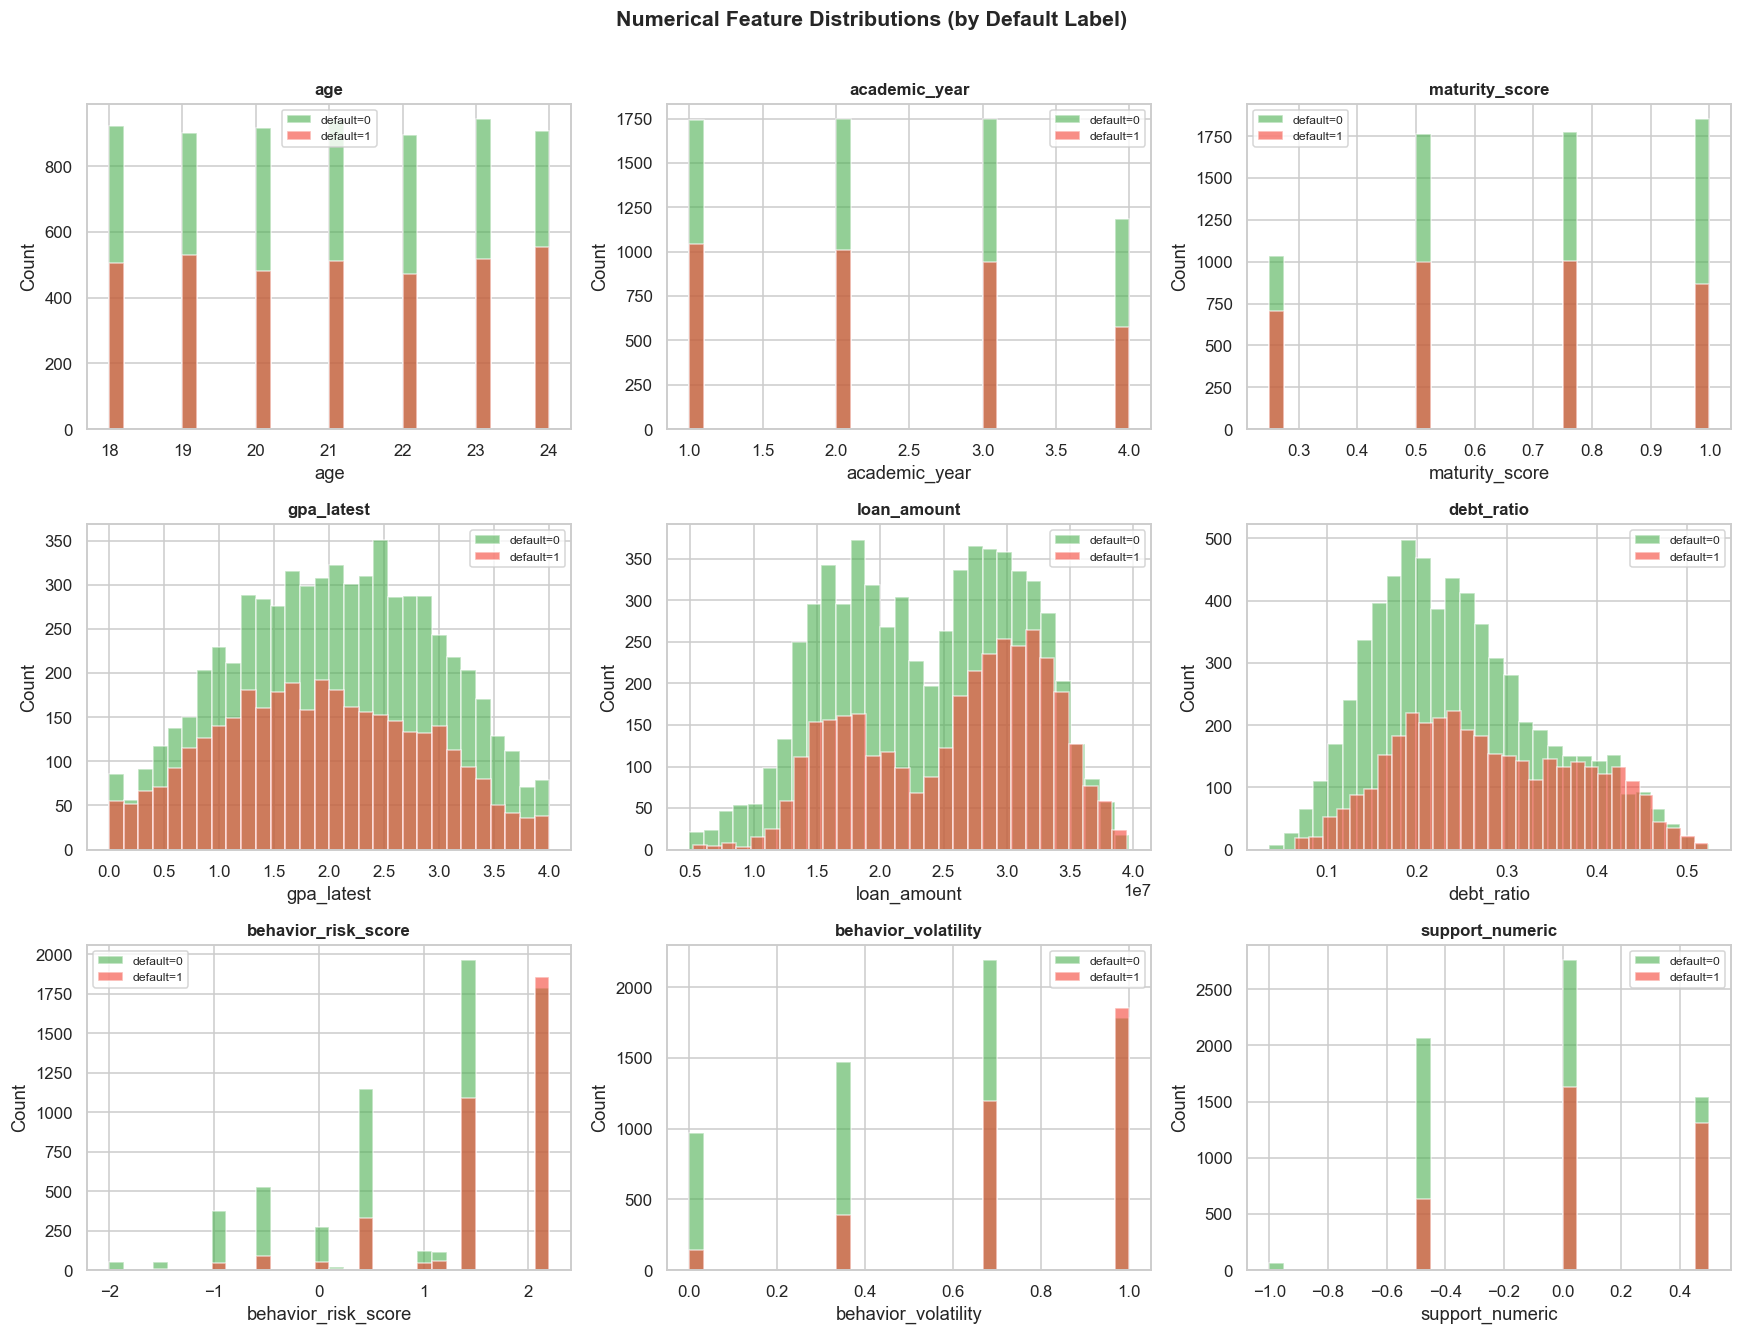

In [6]:
num_features = ['age', 'academic_year', 'maturity_score', 'gpa_latest',
                'loan_amount', 'debt_ratio', 'behavior_risk_score',
                'behavior_volatility', 'support_numeric']

n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

palette = {'0': '#4CAF50', '1': '#F44336'}
for ax, col in zip(axes, num_features):
    for label, grp in df.groupby('default')[col]:
        ax.hist(grp, bins=30, alpha=0.6, label=f'default={label}',
                color=palette[str(label)], edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# Hide unused axes
for ax in axes[len(num_features):]:
    ax.set_visible(False)

plt.suptitle('Numerical Feature Distributions (by Default Label)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

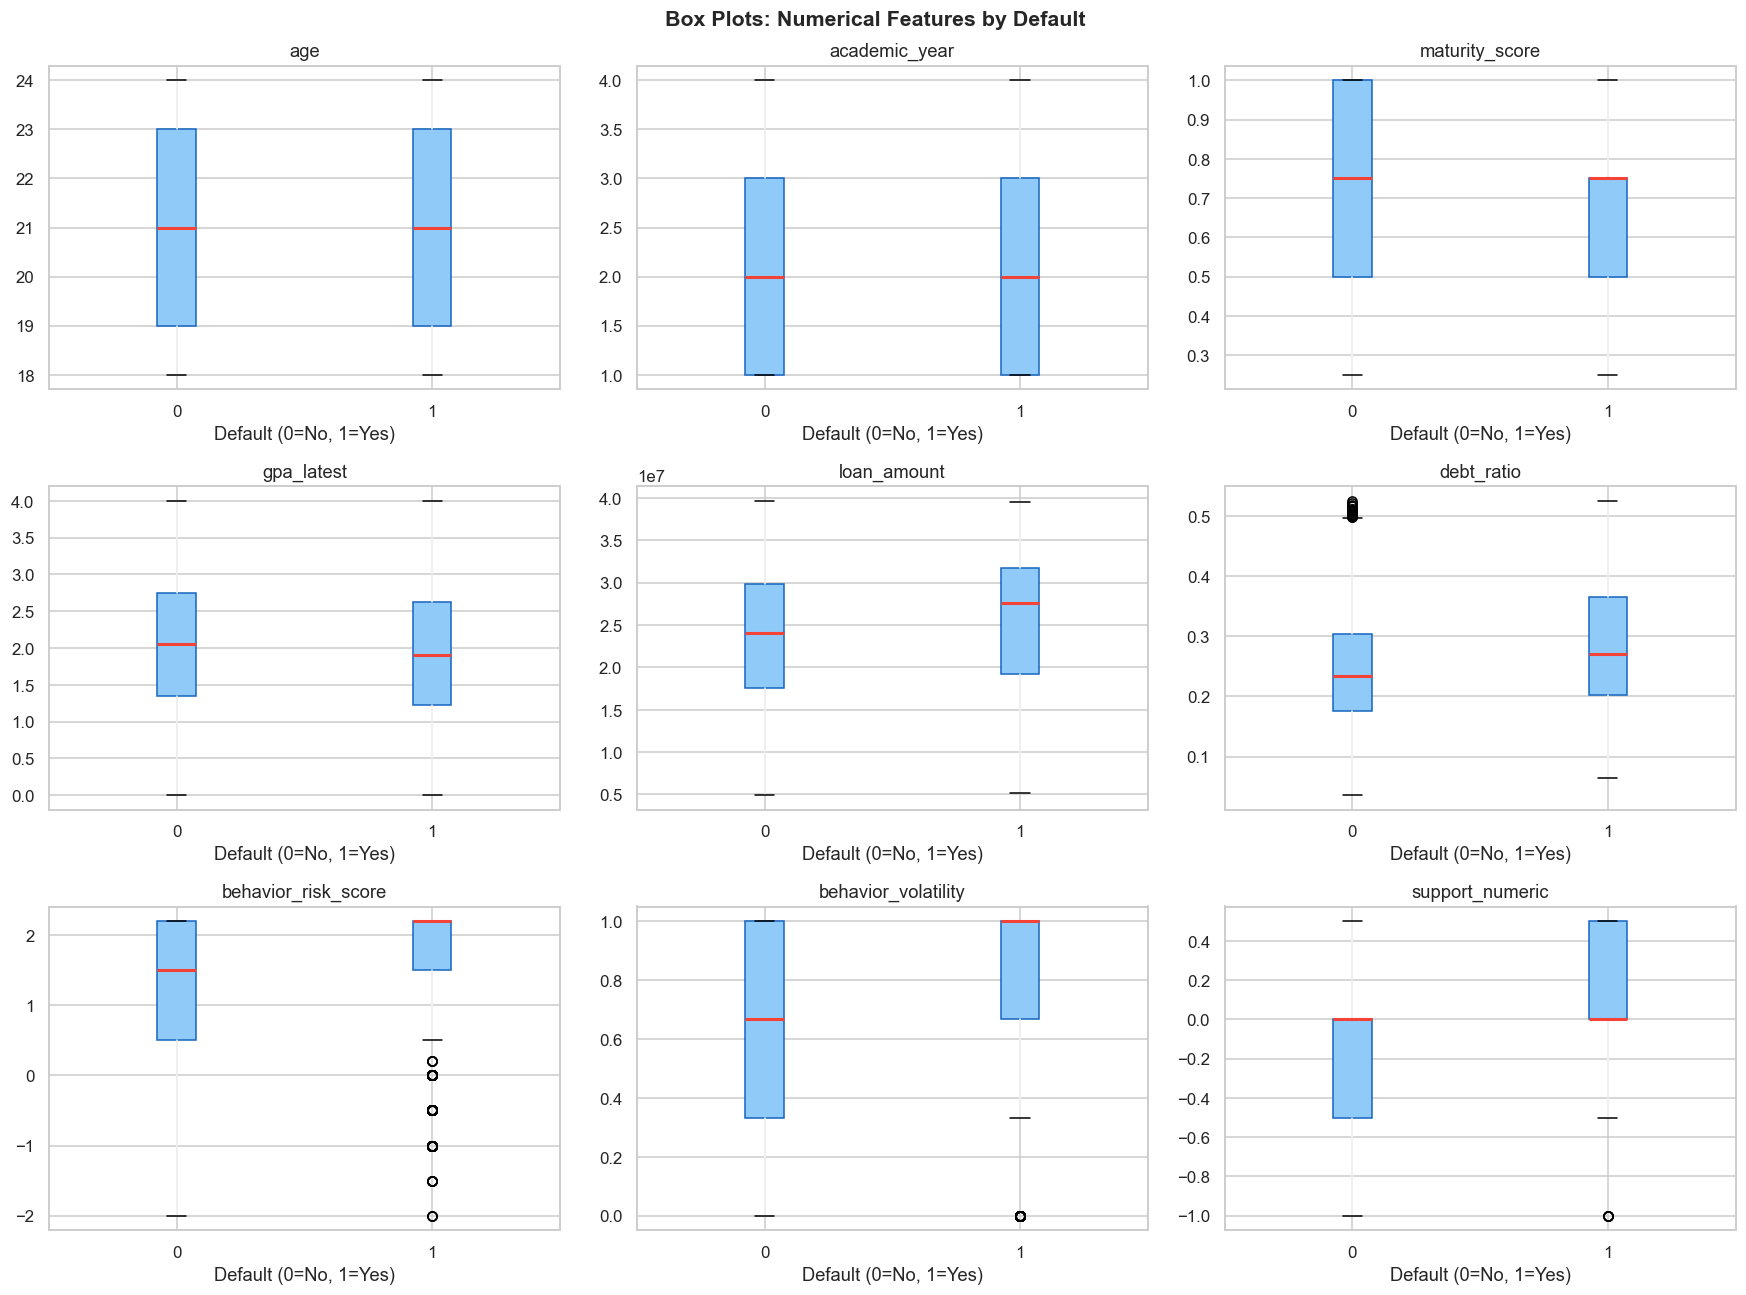

In [7]:
# Box plots — easier to spot median/spread differences
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, num_features):
    df.boxplot(column=col, by='default', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
               medianprops=dict(color='#F44336', linewidth=2))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Default (0=No, 1=Yes)')
    plt.sca(ax); plt.title(col)

for ax in axes[len(num_features):]:
    ax.set_visible(False)

plt.suptitle('Box Plots: Numerical Features by Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

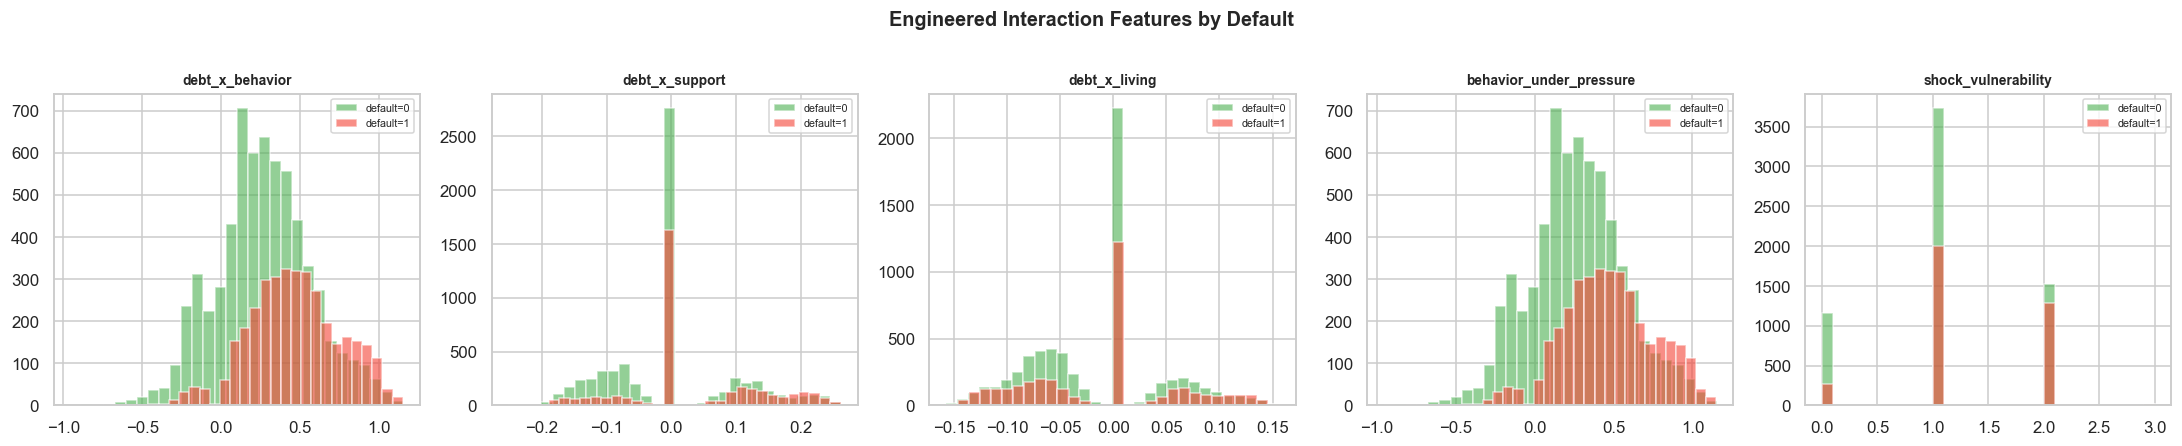

In [8]:
interaction_features = ['debt_x_behavior', 'debt_x_support', 'debt_x_living',
                        'behavior_under_pressure', 'shock_vulnerability']

fig, axes = plt.subplots(1, len(interaction_features), figsize=(20, 4))

for ax, col in zip(axes, interaction_features):
    for label, grp in df.groupby('default')[col]:
        ax.hist(grp, bins=30, alpha=0.6,
                label=f'default={label}',
                color=('#4CAF50' if label == 0 else '#F44336'),
                edgecolor='white')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Engineered Interaction Features by Default', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

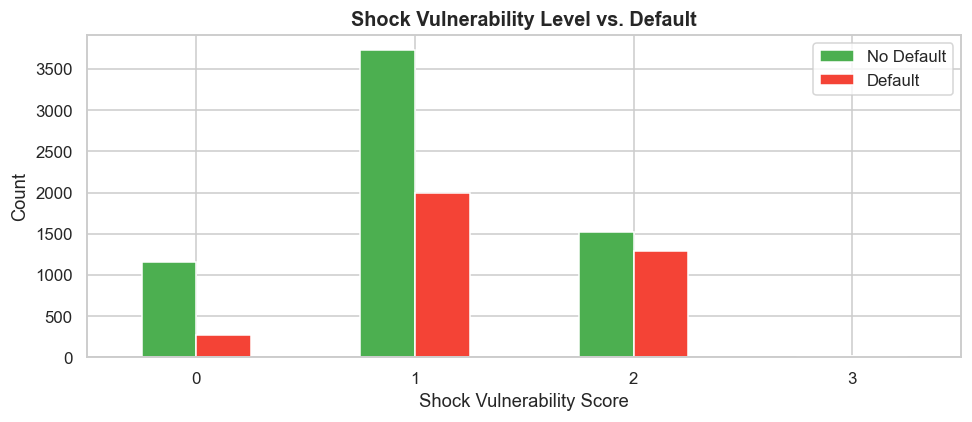

In [9]:
# Shock vulnerability counts
sv_plot = df.groupby(['shock_vulnerability', 'default']).size().unstack(fill_value=0)
sv_plot.plot(kind='bar', figsize=(9, 4), color=['#4CAF50', '#F44336'], edgecolor='white')
plt.title('Shock Vulnerability Level vs. Default', fontsize=13, fontweight='bold')
plt.xlabel('Shock Vulnerability Score')
plt.ylabel('Count')
plt.legend(['No Default', 'Default'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

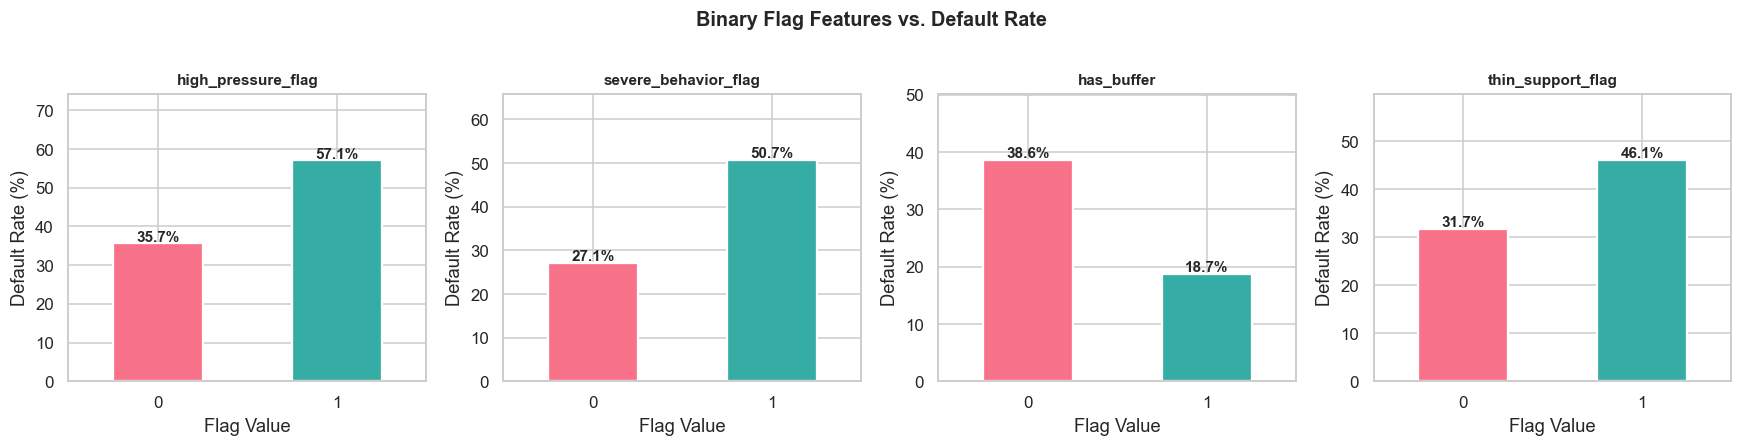

In [10]:
flag_features = ['high_pressure_flag', 'severe_behavior_flag', 'has_buffer', 'thin_support_flag']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, flag_features):
    dr = df.groupby(col)['default'].mean() * 100
    dr.plot(kind='bar', ax=ax,
            color=sns.color_palette('husl', 2),
            edgecolor='white', linewidth=1.5)
    for i, v in enumerate(dr):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Flag Value')
    ax.set_ylabel('Default Rate (%)')
    ax.set_ylim(0, dr.max() * 1.3)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Binary Flag Features vs. Default Rate', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

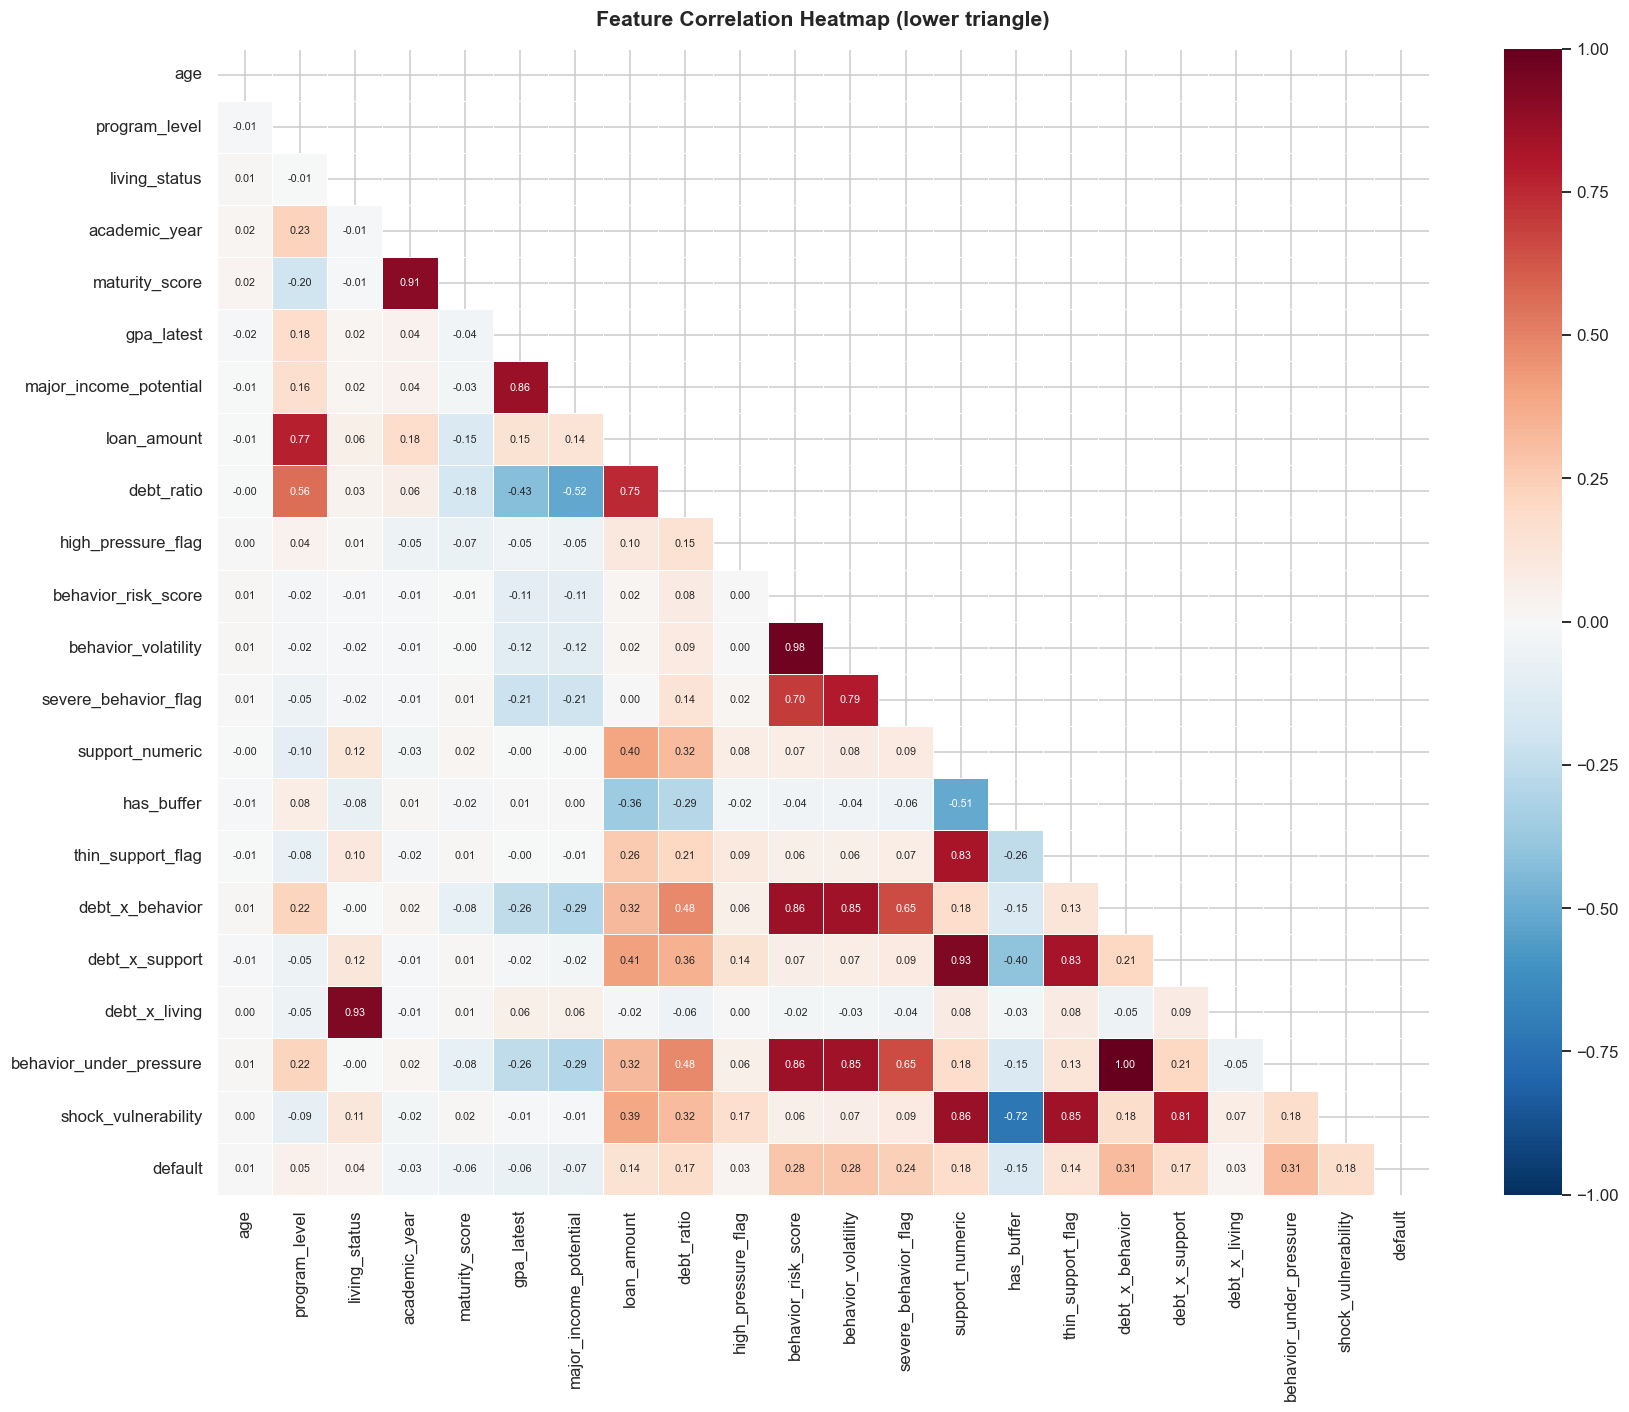

In [11]:
# Encode categoricals for correlation
df_enc = df.copy()
df_enc['program_level']         = df_enc['program_level'].map({'college': 0, 'university': 1})
df_enc['living_status']         = df_enc['living_status'].map({'family': 0, 'dorm': 1, 'rent': 2})
df_enc['major_income_potential'] = df_enc['major_income_potential'].map({'low': 0, 'medium': 1, 'high': 2})
df_enc = df_enc.drop(columns=['user_id'])

corr = df_enc.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Heatmap (lower triangle)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

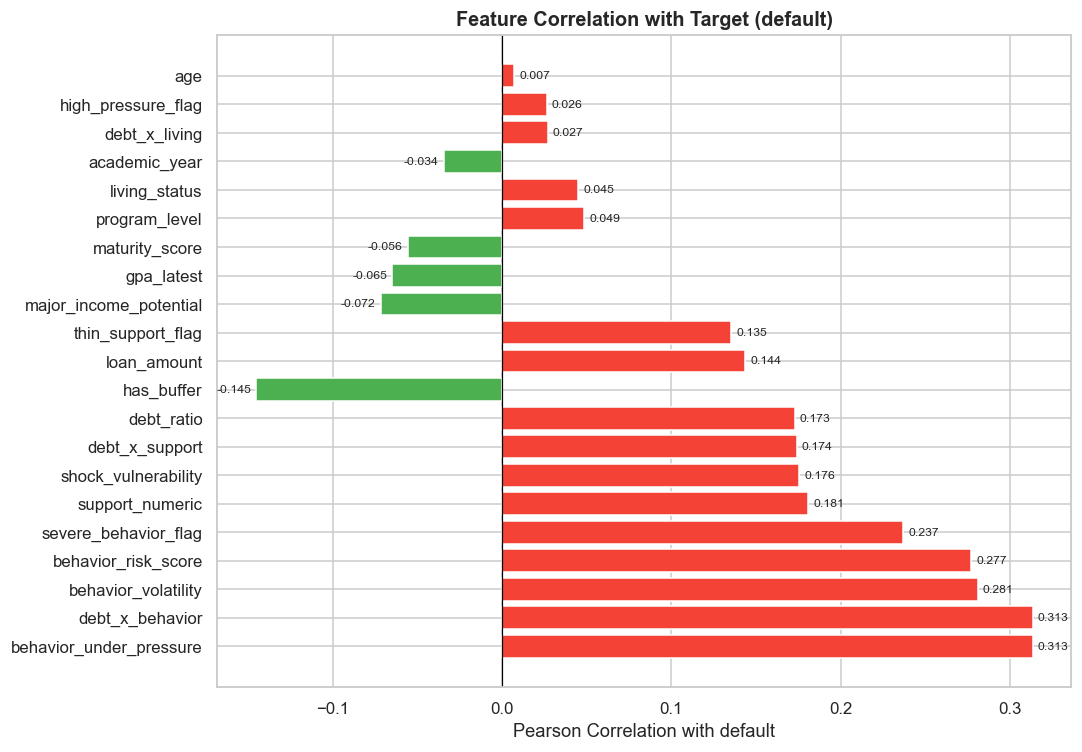

Top 10 features correlated with default:
behavior_under_pressure    0.313370
debt_x_behavior            0.313370
behavior_volatility        0.281088
behavior_risk_score        0.277029
severe_behavior_flag       0.237036
support_numeric            0.180986
shock_vulnerability        0.175637
debt_x_support             0.174198
debt_ratio                 0.172805
has_buffer                -0.145194


In [12]:
# Correlation with target specifically
target_corr = corr['default'].drop('default').sort_values(key=abs, ascending=False)

colors = ['#F44336' if v > 0 else '#4CAF50' for v in target_corr.values]
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with default')
ax.set_title('Feature Correlation with Target (default)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.003 if val >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 10 features correlated with default:')
print(target_corr.head(10).to_string())

In [13]:
print('=' * 60)
print('           DATASET EDA — KEY FINDINGS')
print('=' * 60)

# Class balance
dr = df['default'].mean() * 100
print(f'\n📊 Dataset: {len(df):,} rows × {len(df.columns)} columns')
print(f'🎯 Default rate: {dr:.1f}%  (imbalance ratio: {(1-dr/100)/(dr/100):.2f}:1)')

# Missing / duplicates
print(f'\n✅ Missing values: {df.isnull().sum().sum()}')
print(f'✅ Duplicate rows: {df.duplicated().sum()}')

# Top correlated features
print('\n🔗 Top 5 features correlated with default:')
for feat, val in target_corr.head(5).items():
    direction = '↑ positive' if val > 0 else '↓ negative'
    print(f'   {feat:35s}: {val:+.3f}  {direction}')

# Categorical insights
print('\n📋 Categorical defaults:')
for col in cat_features:
    best = df.groupby(col)['default'].mean().idxmax()
    rate = df.groupby(col)['default'].mean().max() * 100
    print(f'   {col}: highest default in [{best}] at {rate:.1f}%')

print('\n📌 Notes for modeling:')
if dr < 30 or dr > 70:
    print('   ⚠️  Class imbalance detected — consider scale_pos_weight or SMOTE')
print('   💡  Several pre-engineered interaction features exist (debt_x_*, shock_vulnerability)')
print('   💡  GPA and debt_ratio appear to be key discriminators')
print('   💡  Categorical encoding needed for program_level, living_status, major_income_potential')
print('=' * 60)

           DATASET EDA — KEY FINDINGS

📊 Dataset: 10,000 rows × 23 columns
🎯 Default rate: 35.8%  (imbalance ratio: 1.79:1)

✅ Missing values: 0
✅ Duplicate rows: 0

🔗 Top 5 features correlated with default:
   behavior_under_pressure            : +0.313  ↑ positive
   debt_x_behavior                    : +0.313  ↑ positive
   behavior_volatility                : +0.281  ↑ positive
   behavior_risk_score                : +0.277  ↑ positive
   severe_behavior_flag               : +0.237  ↑ positive

📋 Categorical defaults:
   program_level: highest default in [university] at 37.3%
   living_status: highest default in [rent] at 39.8%
   major_income_potential: highest default in [low] at 39.5%

📌 Notes for modeling:
   💡  Several pre-engineered interaction features exist (debt_x_*, shock_vulnerability)
   💡  GPA and debt_ratio appear to be key discriminators
   💡  Categorical encoding needed for program_level, living_status, major_income_potential
